In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import ephem
import math
from datetime import timedelta
import cartopy.crs as ccrs
import cartopy
import matplotlib.path as mpath
from matplotlib.patches import ConnectionPatch


these data are the ERA5 500mb *geopotential* 


In [2]:
# this is the era5 geopotential data (not era interim like the directory implies)
erads = xr.open_dataset("/global/cfs/cdirs/m3779/will_data/era_interim/download.nc")

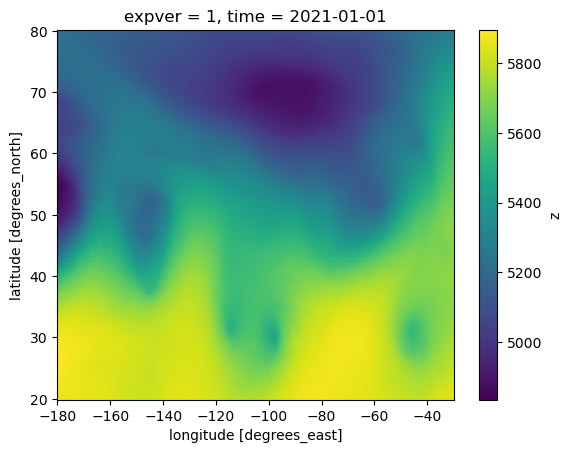

In [3]:
(erads.z/9.81).isel(time=0, expver=0).plot()

these data are the same, but they are the geopotential height anomalies from the entire 1979-2022 period computed
by Lee et. al, 2023.

In [4]:
params = xr.open_dataset("/global/cfs/cdirs/m3779/will_data/era_interim/era5_1979_2022_north_america_regime_z500_params.nc",  decode_times=False)

### plot a little example

In [5]:
params.z_climo#.isel(doy=0).plot()
params.z_climo

<xarray.DataArray 'z_climo' (doy: 365, latitude: 41, longitude: 101)>
[1511465 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 80.0 78.5 77.0 75.5 ... 24.5 23.0 21.5 20.0
  * longitude  (longitude) float32 -180.0 -178.5 -177.0 ... -33.0 -31.5 -30.0
Dimensions without coordinates: doy
Attributes:
    units:      gpm
    long_name:  Daily 1979-2022 ERA5 climate

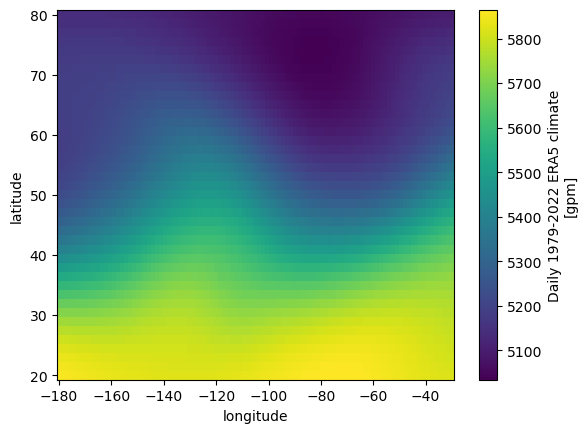

In [6]:
params.z_climo.isel(doy=1).plot()

In [7]:
# coarsen the data to a lower resolution
era_coarsen = erads.isel(expver=0).coarsen(latitude=6, longitude=6, side='left', boundary='pad').mean()

In [8]:
# now, interpolate the data so that it matches the Lee et al. 2023 data
era_coarsen_interp = era_coarsen.interp(latitude = params.latitude, longitude = params.longitude)

In [9]:
params.z_climo

<xarray.DataArray 'z_climo' (doy: 365, latitude: 41, longitude: 101)>
[1511465 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 80.0 78.5 77.0 75.5 ... 24.5 23.0 21.5 20.0
  * longitude  (longitude) float32 -180.0 -178.5 -177.0 ... -33.0 -31.5 -30.0
Dimensions without coordinates: doy
Attributes:
    units:      gpm
    long_name:  Daily 1979-2022 ERA5 climate

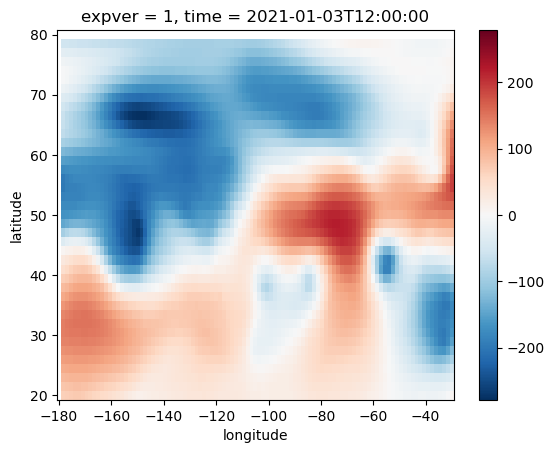

In [10]:
(era_coarsen_interp.isel(time=10).z/9.81 - params.isel(doy=0).z_climo).plot()

In [11]:
# open up the cloud data from SAIL
kolias = xr.open_dataset("/global/homes/r/rudisill/gshare/sail_data_will/data_store_sail_period/kollias/cbh_kolias2.nc").to_pandas()
cloud_present_kolias = kolias.copy()
cloud_present_kolias[cloud_present_kolias == -1] = 0
cloud_present_kolias[cloud_present_kolias > 0] = 1


kolias_lt_6000 = kolias.where(kolias < 6000)
kolias_lt_6000.fillna(-1, inplace=True)
cloud_present_kolias_lt_6000 = kolias_lt_6000.copy()
cloud_present_kolias_lt_6000[cloud_present_kolias_lt_6000 == -1] = 0
cloud_present_kolias_lt_6000[cloud_present_kolias_lt_6000 > 0] = 1


### create a function to make a plot of geopotential height anomalies


In [12]:
#ax = plt.subplot(111, projection=ccrs.NorthPolarStereo(central_longitude=-100))
def make_figure(ax, anom, wind, vmin=-200, vmax=200):
    ax.gridlines()
    ax.coastlines()
    ax.gridlines(alpha=.2)
    ### plot the data 

    cb = ax.pcolormesh(anom.longitude, 
                       anom.latitude, 
                       anom, 
                       cmap='RdBu_r', 
                       transform=ccrs.PlateCarree(), 
                       shading='auto', vmax=vmax, vmin=vmin)

    wind_downsample = wind[{'latitude': slice(None, None, 3), 
                            'longitude': slice(None, None, 3)}]

    # qplot = wind_downsample.plot.quiver('longitude', 
    #                                     'latitude', 
    #                                     'u', 
    #                                     'v',
    #                                     transform=ccrs.PlateCarree(), 
    #                                     scale=250, 
    #                                     ax=ax, 
    #                                     add_guide=False)

    #fig.colorbar(cb, ax=ax, orientation='horizontal')
    ###
    xlim = [-165, -65]
    ylim = [25, 70]

#    xlim = [-140, -80]
#    ylim = [30, 60]

    rect = mpath.Path([[xlim[0], ylim[0]],
                    [xlim[1], ylim[0]],
                    [xlim[1], ylim[1]],
                    [xlim[0], ylim[1]],
                    [xlim[0], ylim[0]],
                    ]).interpolated(20)

    proj_to_data = ccrs.PlateCarree()._as_mpl_transform(ax) - ax.transData
    rect_in_target = proj_to_data.transform_path(rect)
    ax.set_boundary(rect_in_target)

    erw_latitude  = 38.956381  # ERW
    erw_longitude = -106.984322  # ERW

    ax.scatter(erw_longitude, erw_latitude, transform=ccrs.PlateCarree(), s=15, facecolor='black', edgecolor='pink', linewidth=2)
    ax.set_extent([xlim[0], xlim[1], ylim[0], ylim[1]], crs=ccrs.PlateCarree())
    #    ax.set_title(f"500mb Geopotential Height Anomaly (ERA5 1979-2022) \n {the_time}")

    return cb


In [13]:
#cloud_present_kolias_lt_6000_localtime = cloud_present_kolias_lt_6000#.shift(-7, freq='1h')
warmcloud = cloud_present_kolias_lt_6000[cloud_present_kolias_lt_6000.index.month.isin([4,5,6,7,8,9])]
coldcloud = cloud_present_kolias_lt_6000[cloud_present_kolias_lt_6000.index.month.isin([10,11,12,1,2,3])]

### Compute cloud anomalies

### warm seaason

In [14]:
nocloud_warm   = warmcloud.resample("6h").mean()[warmcloud.resample("6h").mean() < .1].dropna()
hicloud_warm   = warmcloud.resample("6h").mean()[warmcloud.resample("6h").mean() > .7].dropna()
midcloud_warm  = warmcloud.resample("6h").mean()[(warmcloud.resample("6h").mean() > .1) & (warmcloud.resample("6h").mean() < .7)].dropna()


In [15]:
# in the code below, we conver the geopotential (m2*s2) to geopotential height (m)
# by dividing by gravity https://codes.ecmwf.int/grib/param-db/129
# the Lee data is already in geopotential height 

In [16]:
anom_nocloud_warm  = era_coarsen_interp.sel(time=nocloud_warm.index).z.mean(dim="time")/9.81 - params.z_climo.loc[params.z_climo.doy.isin(nocloud_warm.index.dayofyear.unique())].mean(dim="doy")
anom_hicloud_warm  = era_coarsen_interp.sel(time=hicloud_warm.index).z.mean(dim="time")/9.81 - params.z_climo.loc[params.z_climo.doy.isin(hicloud_warm.index.dayofyear.unique())].mean(dim="doy")
anom_midcloud_warm = era_coarsen_interp.sel(time=midcloud_warm.index).z.mean(dim="time")/9.81 - params.z_climo.loc[params.z_climo.doy.isin(midcloud_warm.index.dayofyear.unique())].mean(dim="doy")


### do the cold season 

In [17]:
nocloud_cold = coldcloud.resample("6h").mean()[coldcloud.resample("6h").mean() < .1].dropna()
hicloud_cold = coldcloud.resample("6h").mean()[coldcloud.resample("6h").mean() > .7].dropna()


anom_nocloud_cold  = era_coarsen_interp.sel(time=nocloud_cold.index).z.mean(dim="time")/9.81 - params.z_climo.loc[params.z_climo.doy.isin(nocloud_cold.index.dayofyear.unique())].mean(dim="doy")
anom_hicloud_cold  = era_coarsen_interp.sel(time=hicloud_cold.index).z.mean(dim="time")/9.81 - params.z_climo.loc[params.z_climo.doy.isin(hicloud_cold.index.dayofyear.unique())].mean(dim="doy")


In [18]:
len(nocloud_cold), len(hicloud_cold), len(nocloud_warm), len(nocloud_cold)

(452, 704, 256, 452)

### compare the emergence of clouds with the GPT

In [19]:
z_erw = era_coarsen_interp.sel(latitude=38.956381, longitude=-106.984322, method="nearest") 

In [20]:
kol_shr = kolias[kolias > -1].dropna().resample("6h").mean()

In [21]:
cfrac = cloud_present_kolias_lt_6000.resample("6h").mean()

In [22]:
warm_ssn = cfrac[cfrac.index.month.isin([4,5,6,7,8,9])]
cold_ssn = cfrac[cfrac.index.month.isin([10,11,12,1,2,3])]

#warm_ssn[warm_ssn.index.hour.isin([12,18])]

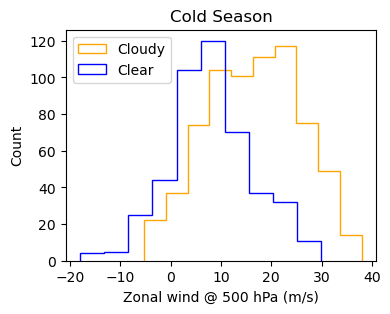

In [23]:
#plt.scatter(warm_ssn z_erw.sel(time=warm_ssn.index).z, s=2)
warm_ssn_cld = warm_ssn[warm_ssn.cloud_base_best_estimate > .7]
warm_ssn_nocld = warm_ssn[warm_ssn.cloud_base_best_estimate < .1]


cold_ssn_cld = cold_ssn[cold_ssn.cloud_base_best_estimate > .7]
cold_ssn_nocld = cold_ssn[cold_ssn.cloud_base_best_estimate < .1]

fig,ax=plt.subplots(figsize=(4,3))

# z_erw.sel(time=warm_ssn_cld.index).u.plot.hist(histtype='step', bins=10, density=False, color='green',ax=ax, label="Cloudy")
# z_erw.sel(time=warm_ssn_nocld.index).u.plot.hist(histtype='step', bins=10, density=False, color='red', ax=ax, label="Clear")
# ax.set_title("Warm Season")


z_erw.sel(time=cold_ssn_cld.index).u.plot.hist(histtype='step', bins=10, density=False, color='orange', ax=ax, label="Cloudy")
z_erw.sel(time=cold_ssn_nocld.index).u.plot.hist(histtype='step', bins=10, density=False, color='blue', ax=ax, label="Clear")
ax.set_title("Cold Season")

ax.set_xlabel("Zonal wind @ 500 hPa (m/s)")
ax.set_ylabel("Count")
ax.legend(loc='upper left')


In [24]:
erw_era5 = z_erw.to_pandas()

In [25]:
erw_era5['u_norm'] = erw_era5.u / np.sqrt(erw_era5.u**2 + erw_era5.v**2)
erw_era5['v_norm'] = erw_era5.v / np.sqrt(erw_era5.u**2 + erw_era5.v**2)

In [26]:
erw_era5['theta'] = np.arctan2(erw_era5.v_norm, erw_era5.u_norm)

In [27]:
def circular_hist(x, bins=16, density=False):
    """
    Produce a circular histogram of angles on ax.

    Parameters
    ----------
    ax : matplotlib.axes._subplots.PolarAxesSubplot
        axis instance created with subplot_kw=dict(projection='polar').

    x : array
        Angles to plot, expected in units of radians.

    bins : int, optional
        Defines the number of equal-width bins in the range. The default is 16.

    density : bool, optional
        If True plot frequency proportional to area. If False plot frequency
        proportional to radius. The default is True.

    offset : float, optional
        Sets the offset for the location of the 0 direction in units of
        radians. The default is 0.

    gaps : bool, optional
        Whether to allow gaps between bins. When gaps = False the bins are
        forced to partition the entire [-pi, pi] range. The default is True.

    Returns
    -------
    n : array or list of arrays
        The number of values in each bin.

    bins : array
        The edges of the bins.

    patches : `.BarContainer` or list of a single `.Polygon`
        Container of individual artists used to create the histogram
        or list of such containers if there are multiple input datasets.
    """
    # Force bins to partition entire circle
    bins = np.linspace(-np.pi, np.pi, num=bins+1)

    # Bin data and record counts
    n, bins = np.histogram(x, bins=bins)

    # Compute width of each bin
    widths = np.diff(bins)

    # By default plot frequency proportional to area
    if density:
        # Area to assign each bin
        area = n / x.size
        # Calculate corresponding bin radius
        radius = (area/np.pi) ** .5

    # Otherwise plot frequency proportional to radius
    else:
        radius = n

    # Plot data on ax
#    patches = ax.bar(bins[:-1], radius, zorder=1, align='edge', width=widths,
#                     edgecolor='None', fill=True, facecolor=color, linewidth=0, alpha=.5, label=label)

    # Set the direction of the zero angle
#    ax.set_theta_offset(offset)

    # Remove ylabels for area plots (they are mostly obstructive)

    return n, bins, radius #patches

In [28]:
erw_era5['speed'] = np.sqrt(erw_era5.u**2 + erw_era5.v**2)

In [29]:
def met_to_trig_convention(u,v):
    # we must flip the data about the y axis and then add 90 degrees 
    phi = np.arctan2(-1*v, u*-1)# - np.pi/2
    return phi

erw_era5['theta_met_convention'] = met_to_trig_convention(erw_era5.u, erw_era5.v)


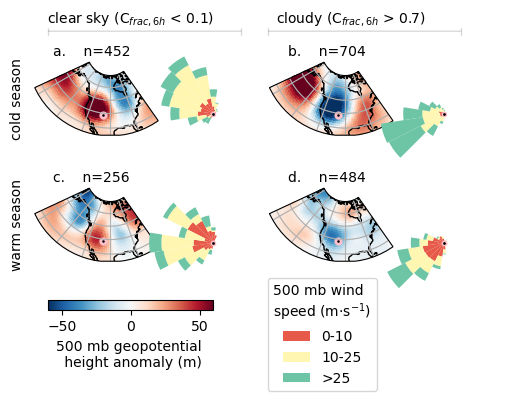

In [31]:
nrows=2
ncols=4
fig, axs = plt.subplots(nrows=nrows,
                        ncols=ncols,
                        subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-100)},
                        figsize=(5.5,3), gridspec_kw={'width_ratios': [1, .6, 1, .4]})


for axzs in [axs[0,1], axs[1,1], axs[0,3], axs[1,3]]:
    axzs.set_visible(False)

                    

cb = make_figure(axs[0,0], anom_nocloud_cold, era_coarsen_interp.sel(time=cold_ssn_nocld.index).mean(dim='time'), vmin=-60, vmax=60)
make_figure(axs[0,2],      anom_hicloud_cold, era_coarsen_interp.sel(time=cold_ssn_cld.index).mean(dim='time'), vmin=-60, vmax=60)


cb = make_figure(axs[1,0], anom_nocloud_warm, era_coarsen_interp.sel(time=warm_ssn_nocld.index).mean(dim='time'), vmin=-60, vmax=60)
make_figure(axs[1,2],      anom_hicloud_warm, era_coarsen_interp.sel(time=warm_ssn_cld.index).mean(dim='time'), vmin=-60, vmax=60)


#cb1 = make_figure(axs[1], hgt_anom_warm, warm_season_cloud_pattern)

axs[0,0].set_title("")
axs[0,2].set_title("")
axs[1,0].set_title("")
axs[1,2].set_title("")

axs[0,0].text(-.2, .5, "cold season", transform=axs[0,0].transAxes, rotation=90, va='center')
axs[1,0].text(-.2, .5, "warm season", transform=axs[1,0].transAxes, rotation=90, va='center')

# label the direction

#len(nocloud_cold), len(hicloud_cold), len(nocloud_warm), len(nocloud_cold)


axs[0,0].text(.15, 1.15, "a.    n=%s"%len(nocloud_cold), transform=axs[0,0].transAxes, rotation=0, va='center')
axs[0,2].text(.15, 1.15, "b.    n=%s"%len(hicloud_cold), transform=axs[0,2].transAxes, rotation=0, va='center')
axs[1,0].text(.15, 1.15, "c.    n=%s"%len(nocloud_warm), transform=axs[1,0].transAxes, rotation=0, va='center')
axs[1,2].text(.15, 1.15, "d.    n=%s"%len(hicloud_warm), transform=axs[1,2].transAxes, rotation=0, va='center')


#cax =  fig.add_axes([.35, 0, 0.3, 0.035])
cax =  fig.add_axes([.15, 0, 0.3, 0.035])
cbar = fig.colorbar(cb, cax=cax, orientation='horizontal')
cbar.set_label("500 mb geopotential \n height anomaly (m)")

################

#fig, ax = plt.subplots(2,2, subplot_kw={'projection': 'polar'})

# # top row 
axa1 = fig.add_axes([.2,  .43,  0.5, 0.45], polar=True, frameon=False)
axa2 = fig.add_axes([.62, .43,  0.5, 0.45], polar=True, frameon=False)

# bottom row 
axa3 = fig.add_axes([.2,  .0,  0.5,  0.45], polar=True, frameon=False)
axa4 = fig.add_axes([.62, .0,  0.5,  0.45], polar=True, frameon=False)


# top row 
# axa1 = fig.add_axes([.2,  .53,  0.4, 0.4], polar=True, frameon=False)
# axa2 = fig.add_axes([.72, .53,  0.4, 0.4], polar=True, frameon=False)

# # bottom row 
# axa3 = fig.add_axes([.2,  .2,  0.4,  0.4], polar=True, frameon=False)
# axa4 = fig.add_axes([.72, .2,  0.4,  0.4], polar=True, frameon=False)




spec_cmap = plt.cm.get_cmap('Spectral', 20)
##### no clouds and warm season 
# low_wind = (erw_era5['theta_met_convention'].loc[cold_ssn_cld.index].where(erw_era5['speed'] < 15).dropna())
# mid_wind = (erw_era5['theta_met_convention'].loc[cold_ssn_cld.index].where(erw_era5['speed'] > 15).dropna())

def make_a_plot(data, ax):
    low_wind = data.where(data['speed'] < 10).theta_met_convention.dropna()
    mid_wind = data.where((data['speed'] > 10) & (data['speed'] < 20)).theta_met_convention.dropna()
    hih_wind = data.where(data['speed'] > 20).theta_met_convention.dropna()
    
    # low winds
    n, bins, radius = circular_hist(low_wind, bins=20)
    widths = [np.diff(bins)[0]]*len(bins[:-1])
    bin_centers = bins[:-1] + np.diff(bins)[0]/2
    bars1 = ax.bar(bin_centers, radius, color=spec_cmap(.15), alpha=1, align='edge', fill=True, width=widths, label='0-10')

    # medium winds 
    n2, bin2, radius2 = circular_hist(mid_wind, bins=20)
    widths = [np.diff(bin2)[0]]*len(bin2[:-1])
    bin_centers = bin2[:-1] + np.diff(bin2)[0]/2
    bars2 = ax.bar(bin_centers, radius2, bottom=radius, color=spec_cmap(.45),  alpha=1, align='edge',fill=True, width=widths, label='10-25')
    
    # high winds 
    n3, bin3, radius3 = circular_hist(hih_wind, bins=20)
    widths = [np.diff(bin3)[0]]*len(bins[:-1])
    bin_centers = bin3[:-1] + np.diff(bin3)[0]/2
    bars3 = ax.bar(bin_centers, radius3, bottom=radius+radius2, color=spec_cmap(.75), alpha=1, align='edge', fill=True,width=widths, label='>25')
    
    # get the handles 
    handles = [bars1, bars2, bars3]
    labels = [bars1[0].get_label(), bars2[0].get_label(), bars3[0].get_label()]
    return handles, labels 

#####
make_a_plot(erw_era5.loc[cold_ssn_nocld.index], axa1)
make_a_plot(erw_era5.loc[cold_ssn_cld.index],  axa2)

make_a_plot(erw_era5.loc[warm_ssn_nocld.index], axa3)
handles, labels = make_a_plot(erw_era5.loc[warm_ssn_cld.index],   axa4)


##### 
# ax[0,0].set_title("Warm Season, No Clouds")
# ax[0,1].set_title("Warm Season, Clouds")
# ax[1,0].set_title("Cold Season, No Clouds")
# ax[1,1].set_title("Cold Season, Clouds")


#ax.set_theta_zero_location('N')
#n, bins, radius = circular_hist((erw_era5['theta_met_convention'].loc[cold_ssn_nocld.index].dropna()), color='red', bins=48, label='clear')
#widths = np.diff(bins)
#ax.bar(bins[:-1], radius, color='red', label='clear', alpha=.5, align='edge', width=widths)

#ax.set_yticks([])
#ax.set_xticks([])
#ax.set_xticks([np.pi/2, 3/4*np.pi, 5/4*np.pi, np.pi, 3*np.pi/2])  
#ax.set_xticklabels(["N", "NE", "W", "SW", "S"])
i=0
for axx in [axa1, axa2, axa3, axa4]:
    axx.set_yticks([])
    axx.set_xticks([3/4*np.pi, 5/4*np.pi, np.pi])
    axx.set_frame_on(False)
    axx.set_axis_off()    
    if i in [0,2]:
        axx.set_xticklabels([])#"NW", "W", "SW"])
    else:
        axx.set_xticklabels([])
    i+=1
    axx.scatter(0,0, s=9, facecolor='black', edgecolor='pink')

#fig.subplots_adjust(wspace=.9)

leg = axa4.legend(handles, ['0-10','10-25', '>25'], ncols=1, loc='lower right', bbox_to_anchor=(.05, -.65))
leg.set_title("500 mb wind\n"+ r"speed (m$\cdot$s$^{-1}$)")



##### draw some connection line things over the two...


fig.text((.15 + .45)*.5, .96, "clear sky (C$_{frac, 6h}$ < 0.1)", transform=fig.transFigure, rotation=0, ha='center')
fig.text((.55 + .85)*.5, .96, "cloudy (C$_{frac, 6h}$ > 0.7)",    transform=fig.transFigure, rotation=0, ha='center')

#fig.transFigure, figure=fig)



# this is the top left one under 'clear sky'
con = ConnectionPatch(
    # in axes coordinates
    xyA =(0.15, .93), coordsA = fig.transFigure,  
    # x in axes coordinates, y in data coordinates
    xyB =(0.5, .93), coordsB = fig.transFigure, 
    mutation_scale=2.5,
    alpha=.15,
    arrowstyle ="|-|")
 
fig.add_artist(con)

# add antother one ..
con = ConnectionPatch(
    # in axes coordinates
    xyA =(0.55, .93), coordsA = fig.transFigure,  
    # x in axes coordinates, y in data coordinates
    xyB =(0.90, .93), coordsB = fig.transFigure, 
    mutation_scale=2.5,
    alpha=.15,
    arrowstyle ="|-|")
 
fig.add_artist(con)

plt.savefig("/global/homes/r/rudisill/gshare2/will_data/cre_project_images/FigureX_era_interim_wind_and_pressure", dpi=300,  bbox_inches="tight")